# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
from src.config import load_default_gene_expression_configs

config1, config2 = load_default_gene_expression_configs('distinct')


todo: Loading testing config from replication deconvolution


In [66]:
from src.gene_expression import read_yl_vst_data_rep
from src.sgd import read_sgd_genes, get_orfname

gene_expression_data = read_yl_vst_data_rep(1)

gene_name = 'DSE1'
orf_name = get_orfname(gene_name)
gene_expression = gene_expression_data.loc[orf_name]


In [82]:
gene_expressions_tpm = pd.read_csv(
    'datasets/yl_cell_cycle/replicate1_gene_expression_TPM.csv')
gene_expressions_tpm = gene_expressions_tpm.set_index('orf_name')


gene_expression_tpm = gene_expressions_tpm.loc[orf_name]

In [136]:
from src.deconvolution_solver import DeconvolutionSolver

g = gene_expression_tpm.values#np.log2(gene_expression_tpm.values+1)
H = config1.H

deconvolution_solver = DeconvolutionSolver(config1, g=g, H=H, gamma=0.0002,
                                          obj_error_mode='additive')


In [138]:
deconvolution_solver.deconvolve()

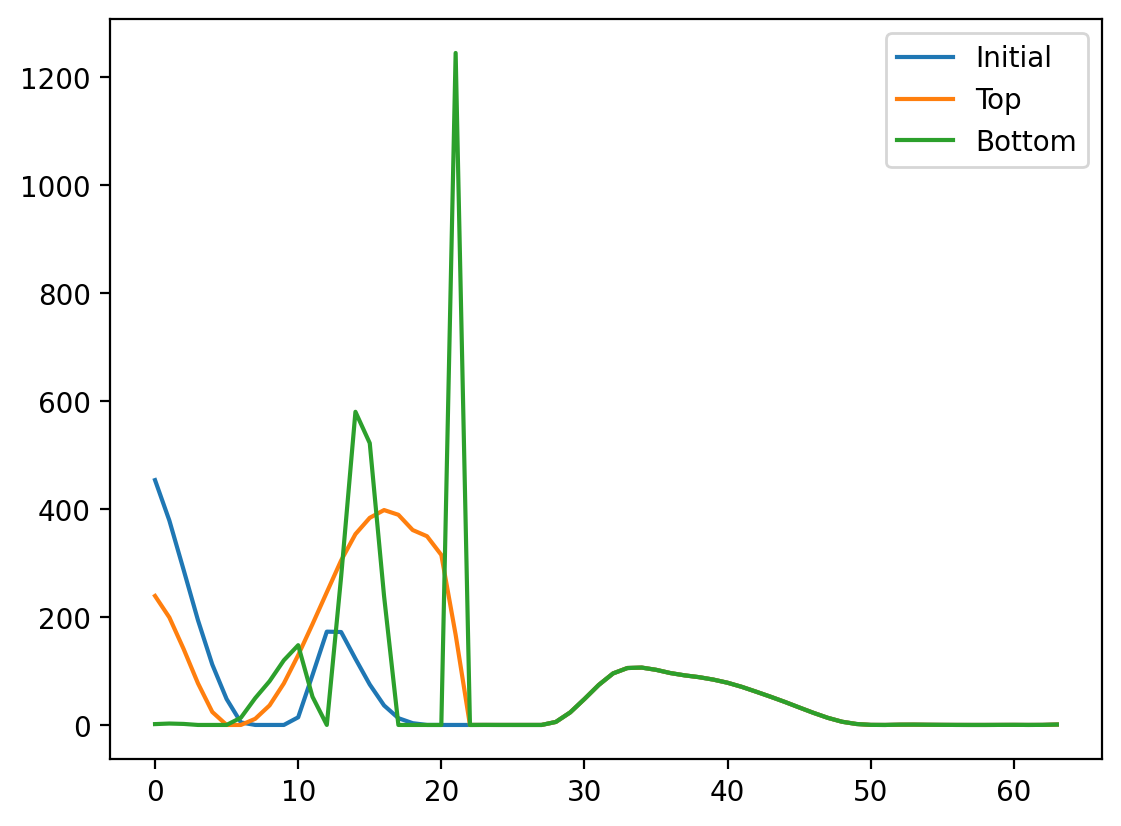

In [139]:
i_indices = config1.get_Hpositions_for_branch('i')
t_indices = config1.get_Hpositions_for_branch('t')
b_indices = config1.get_Hpositions_for_branch('b')

plt.plot(deconvolution_solver.f[i_indices], label="Initial")
plt.plot(deconvolution_solver.f[t_indices], label="Top")
plt.plot(deconvolution_solver.f[b_indices], label="Bottom")
plt.legend()
